# 🔧 Fine-Tuning de LLMs — Guía Completa




---
# 1. ¿Cuándo hacer Fine-Tuning?

## Árbol de decisión

```
¿El modelo base ya conoce la tarea?
    │
    ├─ SÍ → ¿Necesitas adaptar tono/formato/dominio?
    │           ├─ NO → Usa el modelo base con buen prompting
    │           └─ SÍ → ¿Tienes datos propietarios que no puedes enviar a una API?
    │                       ├─ NO → Considera RAG + prompt engineering primero
    │                       └─ SÍ → Fine-tuning PEFT (LoRA/QLoRA)
    │
    └─ NO → ¿El modelo necesita conocimiento factual nuevo o comportamiento nuevo?
                ├─ Conocimiento factual actualizable → RAG (más barato y mantenible)
                ├─ Estilo / tono / formato muy específico → SFT con LoRA
                ├─ Seguir instrucciones especializadas → Instruction tuning
                └─ Alinear con preferencias humanas → SFT → DPO/RLHF
```

## Comparativa de enfoques

| Enfoque | Coste | Datos necesarios | Actualizable | Cuándo usarlo |
|---|---|---|---|---|
| **Prompting** | Muy bajo | 0 | Siempre | Tareas genéricas, prototipado |
| **RAG** | Bajo | Documentos | Sí (en tiempo real) | Conocimiento factual, docs propietarios |
| **LoRA / QLoRA** | Medio | 1K–100K ejemplos | Reentrenar adaptador | Estilo, dominio, instrucciones |
| **Full fine-tuning** | Muy alto | 100K+ ejemplos | Reentrenar todo | Cambio profundo de dominio |
| **Pretraining** | Extremo | Billones de tokens | No aplica | Modelo base desde cero |

## ¿Cuántos datos necesitas?

| Cantidad | Técnica recomendada | Expectativa |
|---|---|---|
| < 100 ejemplos | Few-shot prompting | Mejora marginal |
| 100–1K | LoRA (rank bajo, r=8) | Adaptación de tono/formato |
| 1K–50K | QLoRA (r=16–32) | El sweet spot industrial |
| 50K–500K | DoRA / LoRA rank alto | Cambio significativo de dominio |
| 500K+ | Full fine-tuning | Cambio estructural profundo |

In [ ]:
!pip install transformers datasets peft trl bitsandbytes accelerate
!pip install torch torchvision sentencepiece huggingface_hub
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.0/531.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.7 MB/s eta 0:00:00
  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-tlmcbp7g/unsloth_3a064cd6ac19438998e6aa5dcc3394ad
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-tlmcbp7g/unsloth_3a064cd6ac19438998e6aa5dcc3394ad
  Resolved https://github.com/unslothai/unsloth.git to commit 6d83ad9a2834fc84cb39bd2a2fe2ba0ceb8d8262
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.2/403.2 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 86.5 MB/s eta 0:00:00
  

In [1]:
# ============================================================
#  SETUP — Instalación y configuración
# ============================================================

import os
import re
import json
import math
import copy
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ── Estilo visual ──────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',   'axes.labelcolor': '#e6edf3',
    'xtick.color': '#8b949e',      'ytick.color': '#8b949e',
    'text.color': '#e6edf3',       'grid.color': '#21262d',
    'grid.alpha': 0.5,             'font.size': 11,
    'axes.titlesize': 13,          'axes.titleweight': 'bold',
    'legend.facecolor': '#161b22', 'legend.edgecolor': '#30363d',
})
PALETTE = ['#58a6ff','#ff7b72','#3fb950','#d2a8ff',
           '#ffa657','#79c0ff','#f85149','#56d364']

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Setup completado')
print(f' Device  : {device}')
print(f' PyTorch : {torch.__version__}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

✅ Setup completado
 Device  : cpu
 PyTorch : 2.10.0+cpu


---
# 2. Full Fine-Tuning — Fundamentos y Coste

El full fine-tuning actualiza **todos los parámetros** del modelo. Para un LLM con $N$ parámetros, el consumo de memoria durante el entrenamiento es:

$$\text{VRAM} \approx N \times (\underbrace{2}_\text{pesos fp16} + \underbrace{2}_\text{gradientes} + \underbrace{8}_\text{estado Adam}) = N \times 12 \text{ bytes}$$

Para un modelo de 7B parámetros: $7 \times 10^9 \times 12 \approx 84$ GB de VRAM.

### El problema del Catastrophic Forgetting

Al actualizar todos los pesos con datos de un dominio estrecho, el modelo "olvida" el conocimiento general aprendido en pretraining. Soluciones:
- **Regularización L2** hacia los pesos originales
- **EWC** (Elastic Weight Consolidation) — penaliza cambios en pesos críticos
- **Mezcla de datos generales** (20–30%) con los datos del dominio
- **PEFT** — congelar el modelo base y solo entrenar adaptadores

Modelo          Full FT         LoRA        QLoRA
──────────────────────────────────────────────────
1B               12.3GB        2.3GB        0.6GB
3B               36.9GB        7.0GB        1.7GB
7B               86.1GB       16.3GB        4.0GB
13B             159.9GB       30.3GB        7.5GB
30B             369.0GB       70.0GB       17.3GB
70B             861.0GB      163.3GB       40.3GB


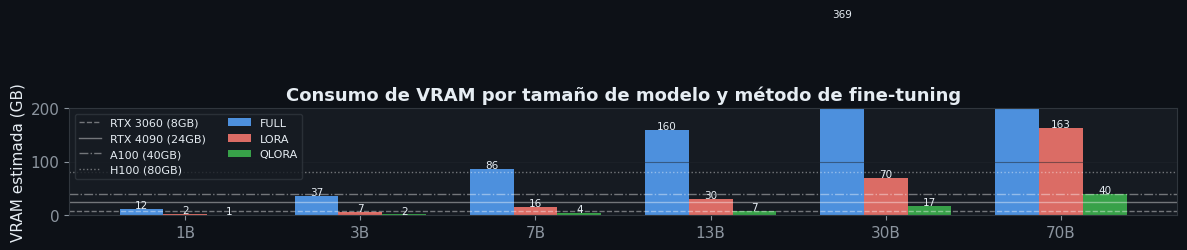

In [2]:
# ============================================================
#  CALCULADORA DE MEMORIA PARA FINE-TUNING
# ============================================================

def calcular_vram_finetuning(n_params_B: float,
                              precision: str = 'bf16',
                              metodo: str = 'full',
                              lora_rank: int = 16,
                              lora_target_pct: float = 0.35) -> dict:
    """
    Estima VRAM necesaria para fine-tuning.

    Parámetros
    ----------
    n_params_B      : tamaño del modelo en miles de millones
    precision       : 'fp32', 'bf16', 'fp16', 'int8', 'int4'
    metodo          : 'full', 'lora', 'qlora'
    lora_rank       : rank r de LoRA
    lora_target_pct : fracción de parámetros donde se aplica LoRA (~0.35 para all-linear)
    """
    N = n_params_B * 1e9

    bits_modelo = {'fp32': 32, 'bf16': 16, 'fp16': 16,
                   'int8': 8, 'int4': 4}[precision]

    bytes_modelo = N * bits_modelo / 8

    if metodo == 'full':
        bytes_grads     = N * 2  # fp16 gradientes
        bytes_optimizer = N * 8  # Adam: momento 1 + 2, ambos fp32
        bytes_activaciones = bytes_modelo * 0.15  # aprox
        total = bytes_modelo + bytes_grads + bytes_optimizer + bytes_activaciones
        params_entrenables = N

    elif metodo == 'lora':
        # Solo los adaptadores LoRA son entrenables
        # Parámetros LoRA ≈ 2 * rank * d_model * n_capas_target
        params_lora = N * lora_target_pct * (2 * lora_rank) / 4096  # estimación
        bytes_grads = params_lora * 4  # fp32
        bytes_optimizer = params_lora * 8
        bytes_activaciones = bytes_modelo * 0.15
        total = bytes_modelo + bytes_grads + bytes_optimizer + bytes_activaciones
        params_entrenables = params_lora

    else:  # qlora
        # Modelo base en int4, adaptadores en bf16
        bytes_modelo = N * 4 / 8  # int4
        params_lora = N * lora_target_pct * (2 * lora_rank) / 4096
        bytes_lora = params_lora * 2  # bf16
        bytes_grads = params_lora * 4
        bytes_optimizer = params_lora * 8
        bytes_activaciones = N * 2 / 8 * 0.15
        total = bytes_modelo + bytes_lora + bytes_grads + bytes_optimizer + bytes_activaciones
        params_entrenables = params_lora

    return {
        'modelo_GB': bytes_modelo / 1e9,
        'total_GB': total / 1e9,
        'params_B': n_params_B,
        'params_entrenables_M': params_entrenables / 1e6,
        'pct_entrenables':   params_entrenables / N * 100,
    }


# ── Comparativa de métodos y tamaños ──────────────────────
modelos = [1, 3, 7, 13, 30, 70]
metodos = ['full', 'lora', 'qlora']
precision  = {'full': 'bf16', 'lora': 'bf16', 'qlora': 'int4'}

print(f'{"Modelo":<10} {"Full FT":>12} {"LoRA":>12} {"QLoRA":>12}')
print('─' * 50)
resultados_vram = {}
for n in modelos:
    row = {}
    for m in metodos:
        r = calcular_vram_finetuning(n, precision[m], m)
        row[m] = r['total_GB']
    resultados_vram[n] = row
    print(f'{str(n)+"B":<10} {row["full"]:>10.1f}GB {row["lora"]:>10.1f}GB {row["qlora"]:>10.1f}GB')

# Visualización
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(modelos))
w = 0.25
for i, (m, color) in enumerate(zip(metodos, PALETTE[:3])):
    vals = [resultados_vram[n][m] for n in modelos]
    ax.bar(x + i*w, vals, w, label=m.upper(), color=color, alpha=0.85)
    for xi, v in zip(x + i*w, vals):
        if v < 500:
            ax.text(xi, v + 1, f'{v:.0f}', ha='center', fontsize=7.5)

# Líneas de referencia de GPUs comunes
for vram, nombre, ls in [(8,'RTX 3060 (8GB)','--'), (24,'RTX 4090 (24GB)','-'),
                          (40,'A100 (40GB)','-.'),(80,'H100 (80GB)',':')]:
    ax.axhline(vram, color='white', lw=1, ls=ls, alpha=0.4, label=nombre)

ax.set_xticks(x + w)
ax.set_xticklabels([f'{n}B' for n in modelos])
ax.set_ylabel('VRAM estimada (GB)')
ax.set_title('Consumo de VRAM por tamaño de modelo y método de fine-tuning')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, axis='y')
ax.set_ylim(0, 200)
plt.tight_layout()
plt.savefig('ft_vram_comparativa.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()

---
# 3. Formatos de Datos — Instruction Tuning

El formato de los datos de entrenamiento es tan importante como la técnica. Los LLMs modernos usan **chat templates** para estructurar las conversaciones.

In [3]:
# ============================================================
#  FORMATOS DE DATOS — Instruction Tuning
# ============================================================

# ── 1. Formato Alpaca (instrucción + input + output) ──────
ejemplo_alpaca = {
    'instruction': 'Resume el siguiente texto en una frase.',
    'input':       'Los transformers son modelos de deep learning que usan mecanismos '
                   'de atención para procesar secuencias en paralelo.',
    'output':      'Los transformers son redes neuronales que procesan secuencias '
                   'en paralelo mediante atención.'
}

ALPACA_TEMPLATE = (
    '### Instruction:\n{instruction}\n\n'
    '### Input:\n{input}\n\n'
    '### Response:\n{output}'
)

# ── 2. Formato ChatML (OpenAI / modelos modernos) ─────────
ejemplo_chatml = [
    {'role': 'system', 'content': 'Eres un asistente experto en IA.'},
    {'role': 'user', 'content': '¿Qué es un transformer?'},
    {'role': 'assistant', 'content': 'Un transformer es una arquitectura de '
                                     'red neuronal basada en mecanismos de atención.'}
]

CHATML_TEMPLATE = (
    '<|im_start|>system\n{system}<|im_end|>\n'
    '<|im_start|>user\n{user}<|im_end|>\n'
    '<|im_start|>assistant\n{assistant}<|im_end|>'
)

# ── 3. Formato Llama 3 (el más usado en 2025) ─────────────
LLAMA3_TEMPLATE = (
    '<|begin_of_text|>'
    '<|start_header_id|>system<|end_header_id|>\n\n'
    '{system}<|eot_id|>'
    '<|start_header_id|>user<|end_header_id|>\n\n'
    '{user}<|eot_id|>'
    '<|start_header_id|>assistant<|end_header_id|>\n\n'
    '{assistant}<|eot_id|>'
)

# ── 4. Formato para DPO/ORPO (pares preferencia) ─────────
ejemplo_dpo = {
    'prompt':   '¿Cuál es la capital de Francia?',
    'chosen':   'La capital de Francia es París, una de las ciudades '
                'más visitadas del mundo con más de 2 millones de habitantes.',
    'rejected': 'Francia tiene muchas ciudades bonitas.'
}

# ── Dataset sintético de ejemplo ─────────────────────────
DATASET_SFT = [
    {
        'instruction': 'Explica qué es el fine-tuning en LLMs.',
        'input':       '',
        'output':      'El fine-tuning adapta un LLM preentrenado a tareas '
                       'específicas actualizando sus pesos con datos nuevos. '
                       'Técnicas como LoRA lo hacen eficiente en memoria.'
    },
    {
        'instruction': 'Escribe una función Python que calcule el factorial.',
        'input':       '',
        'output':      'def factorial(n):\n    if n <= 1: return 1\n    return n * factorial(n-1)'
    },
    {
        'instruction': 'Traduce al inglés.',
        'input':       'La inteligencia artificial está transformando el mundo.',
        'output':      'Artificial intelligence is transforming the world.'
    },
]

def formatear_alpaca(ejemplo: dict) -> str:
    if ejemplo['input']:
        return ALPACA_TEMPLATE.format(**ejemplo)
    return f"### Instruction:\n{ejemplo['instruction']}\n\n### Response:\n{ejemplo['output']}"


print('── Formato Alpaca ──')
print(formatear_alpaca(DATASET_SFT[0]))

print('\n── Formato ChatML ──')
print(CHATML_TEMPLATE.format(
    system='Eres un asistente experto en IA.',
    user='¿Qué es un transformer?',
    assistant='Un transformer es una arquitectura de red neuronal basada en mecanismos de atención.'
))

print('\n── Formato DPO (chosen/rejected) ──')
print(json.dumps(ejemplo_dpo, ensure_ascii=False, indent=2))

── Formato Alpaca ──
### Instruction:
Explica qué es el fine-tuning en LLMs.

### Response:
El fine-tuning adapta un LLM preentrenado a tareas específicas actualizando sus pesos con datos nuevos. Técnicas como LoRA lo hacen eficiente en memoria.

── Formato ChatML ──
<|im_start|>system
Eres un asistente experto en IA.<|im_end|>
<|im_start|>user
¿Qué es un transformer?<|im_end|>
<|im_start|>assistant
Un transformer es una arquitectura de red neuronal basada en mecanismos de atención.<|im_end|>

── Formato DPO (chosen/rejected) ──
{
  "prompt": "¿Cuál es la capital de Francia?",
  "chosen": "La capital de Francia es París, una de las ciudades más visitadas del mundo con más de 2 millones de habitantes.",
  "rejected": "Francia tiene muchas ciudades bonitas."
}


---
# 4. LoRA — Low-Rank Adaptation desde Cero

## Intuición matemática

Durante el fine-tuning, los cambios en los pesos $\Delta W$ tienen una **dimensionalidad intrínseca baja**. En lugar de aprender $\Delta W \in \mathbb{R}^{d \times k}$ completo, se factoriza:

$$\Delta W = BA \quad \text{donde } B \in \mathbb{R}^{d \times r},\; A \in \mathbb{R}^{r \times k},\; r \ll \min(d, k)$$

La salida de la capa modificada es:

$$h = W_0 x + \Delta W x = W_0 x + \frac{\alpha}{r} B A x$$

donde $\alpha$ es el hiperparámetro de escala (`lora_alpha`).

**Inicialización**: $A \sim \mathcal{N}(0, \sigma^2)$ (random), $B = 0$ → $\Delta W = 0$ al inicio, el modelo empieza siendo el modelo base.

**Reducción de parámetros**: Para una capa $d \times k$ con rank $r$:
$$\text{Parámetros LoRA} = r(d + k) \ll dk \text{ (parámetros originales)}$$

Para $d=k=4096$, $r=16$: $16 \times 8192 = 131K$ vs $4096^2 = 16.7M$ → **127x menos parámetros**.

In [5]:
# ============================================================
#  LORA DESDE CERO — Implementación en PyTorch
# ============================================================

class LoRALayer(nn.Module):
    """
    Capa LoRA que envuelve un nn.Linear existente.
    Añade las matrices A y B entrenables; congela los pesos originales.
    """

    def __init__(self, linear: nn.Linear,
                  r: int      = 16,
                  alpha: float = 16.0,
                  dropout: float = 0.0):
        super().__init__()
        self.linear = linear
        self.r = r
        self.alpha = alpha
        self.scaling = alpha / r
        d_out, d_in = linear.weight.shape

        # Congelar pesos originales
        self.linear.weight.requires_grad_(False)
        if self.linear.bias is not None:
            self.linear.bias.requires_grad_(False)

        # Matrices LoRA entrenables
        self.lora_A = nn.Parameter(torch.empty(r, d_in))
        self.lora_B = nn.Parameter(torch.zeros(d_out, r))
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        # Inicialización: A ~ N(0, 0.02), B = 0 → ΔW = 0 al inicio
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Salida original (congelada)
        base_out = self.linear(x)
        # Contribución LoRA: scaling * B @ A @ x
        lora_out = self.scaling * (self.dropout(x) @ self.lora_A.T @ self.lora_B.T)
        return base_out + lora_out

    def merge(self) -> nn.Linear:
        """Fusiona los pesos LoRA en el linear original (para inferencia)."""
        merged = copy.deepcopy(self.linear)
        merged.weight.data += self.scaling * (self.lora_B @ self.lora_A)
        merged.weight.requires_grad_(True)
        return merged

    def n_params_trainable(self) -> int:
        return self.lora_A.numel() + self.lora_B.numel()

    def n_params_total(self) -> int:
        return self.linear.weight.numel() + self.n_params_trainable()


class LoRAModel(nn.Module):
    """
    Aplica LoRA a los módulos nn.Linear indicados de un modelo existente.
    """

    def __init__(self, model: nn.Module,
                  target_modules: list[str],
                  r: int = 16,
                  alpha: float = 16.0,
                  dropout: float = 0.05):
        super().__init__()
        self.model = model

        # Congelar todo el modelo base primero
        for p in self.model.parameters():
            p.requires_grad_(False)

        # Reemplazar capas target con LoRALayer
        self._aplicar_lora(model, target_modules, r, alpha, dropout)

    def _aplicar_lora(self, module: nn.Module, targets: list,
                       r: int, alpha: float, dropout: float,
                       prefix: str = ''):
        for nombre, hijo in module.named_children():
            ruta = f'{prefix}.{nombre}' if prefix else nombre
            if isinstance(hijo, nn.Linear) and any(t in nombre for t in targets):
                setattr(module, nombre, LoRALayer(hijo, r, alpha, dropout))
            else:
                self._aplicar_lora(hijo, targets, r, alpha, dropout, ruta)

    def forward(self, *args, **kwargs):
        return self.model(*args, **kwargs)

    def stats(self) -> dict:
        total      = sum(p.numel() for p in self.parameters())
        entrenables = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return {
            'total_params':      total,
            'trainable_params':  entrenables,
            'frozen_params':     total - entrenables,
            'pct_trainable':     entrenables / total * 100
        }


# ── Demo con un MLP simple ────────────────────────────────

class MLP(nn.Module):
    def __init__(self, d_in=512, d_hidden=2048, d_out=512, n_layers=4):
        super().__init__()
        layers = [nn.Linear(d_in, d_hidden), nn.GELU()]
        for _ in range(n_layers - 2):
            layers += [nn.Linear(d_hidden, d_hidden), nn.GELU()]
        layers.append(nn.Linear(d_hidden, d_out))
        self.net = nn.Sequential(*layers)

    def forward(self, x): return self.net(x)


modelo_base = MLP()
total_base  = sum(p.numel() for p in modelo_base.parameters())

# Aplicar LoRA solo a las capas lineales del nombre 'net'
lora_model = LoRAModel(modelo_base, target_modules=['0','2','4','6'],
                        r=8, alpha=16.0)
stats = lora_model.stats()

print('── Estadísticas del modelo con LoRA ──')
print(f'Parámetros totales: {stats["total_params"]:>12,}')
print(f'Parámetros entrenables: {stats["trainable_params"]:>12,}')
print(f'Parámetros congelados : {stats["frozen_params"]:>12,}')
print(f'% entrenables: {stats["pct_trainable"]:>11.2f}%')

# Verificar que ΔW = 0 al inicio
x_test = torch.randn(2, 512)
with torch.no_grad():
    out_lora = lora_model(x_test)
    out_base = modelo_base(x_test)
print(f'\n  ΔW = 0 al inicio: {torch.allclose(out_lora, out_base, atol=1e-6)}')

── Estadísticas del modelo con LoRA ──
Parámetros totales:   10,598,912
Parámetros entrenables:      106,496
Parámetros congelados :   10,492,416
% entrenables:        1.00%

  ΔW = 0 al inicio: True


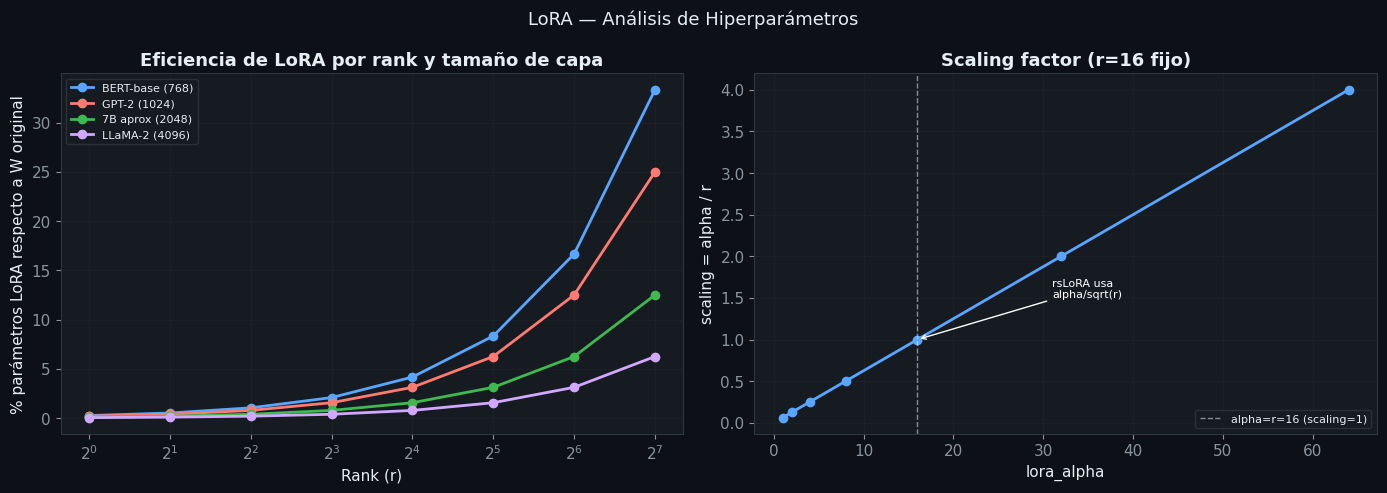

In [6]:
# ── Visualizar reducción de parámetros por rank ───────────

ranks  = [1, 2, 4, 8, 16, 32, 64, 128]
d_vals = [768, 1024, 2048, 4096]   # d_model típicos de distintos LLMs
labels = ['BERT-base (768)', 'GPT-2 (1024)', '7B aprox (2048)', 'LLaMA-2 (4096)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LoRA — Análisis de Hiperparámetros', fontsize=13)

# Reducción de parámetros
for d, lbl, color in zip(d_vals, labels, PALETTE[:4]):
    pct_lora = [2*r*d / (d*d) * 100 for r in ranks]
    axes[0].plot(ranks, pct_lora, 'o-', color=color, lw=2, label=lbl)

axes[0].set_xlabel('Rank (r)')
axes[0].set_ylabel('% parámetros LoRA respecto a W original')
axes[0].set_title('Eficiencia de LoRA por rank y tamaño de capa')
axes[0].legend(fontsize=8)
axes[0].grid(True)
axes[0].set_xscale('log', base=2)

# Impacto de lora_alpha / r (el scaling factor)
alphas = [1, 2, 4, 8, 16, 32, 64]
r_fixed = 16
scalings = [a/r_fixed for a in alphas]
axes[1].plot(alphas, scalings, 'o-', color=PALETTE[0], lw=2)
axes[1].axvline(r_fixed, color='white', lw=1, ls='--', alpha=0.5, label=f'alpha=r={r_fixed} (scaling=1)')
axes[1].set_xlabel('lora_alpha')
axes[1].set_ylabel('scaling = alpha / r')
axes[1].set_title(f'Scaling factor (r={r_fixed} fijo)')
axes[1].legend(fontsize=8)
axes[1].grid(True)
axes[1].annotate('rsLoRA usa\nalpha/sqrt(r)', xy=(r_fixed, 1),
                  xytext=(r_fixed+15, 1.5),
                  arrowprops=dict(arrowstyle='->', color='white'),
                  color='white', fontsize=8)

plt.tight_layout()
plt.savefig('lora_hyperparams.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()

---
# 5. QLoRA — Cuantización + LoRA

QLoRA combina tres innovaciones para reducir la VRAM ~4x respecto a LoRA estándar:

1. **NF4 (NormalFloat 4-bit)**: tipo de datos de 4 bits optimizado para la distribución de pesos de redes neuronales (distribución normal). Minimiza el error de cuantización frente a INT4 genérico.

2. **Double Quantization**: cuantiza también las constantes de cuantización (los factores de escala), ahorrando ~0.5 bits por parámetro adicionales.

3. **Paged Optimizers**: usa la memoria unificada de CUDA para hacer paging del estado del optimizador a RAM CPU durante picos de memoria, evitando OOM.

**Clave**: el modelo base se almacena y computa en NF4 (inferencia), pero los gradientes y los adaptadores LoRA se mantienen en BF16. QLoRA es **memory-quantized, not compute-quantized**.

$$\text{VRAM QLoRA} \approx \underbrace{N \times \frac{4}{8}}_\text{modelo NF4} + \underbrace{P_{LoRA} \times \frac{16}{8}}_\text{adaptadores BF16} + \underbrace{P_{LoRA} \times 4}_\text{optimizer}$$

── Código QLoRA (referencia) ──

from transformers import BitsAndBytesConfig, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
import torch

# ── 1. Configuración de cuantización NF4 ─────────────────
bnb_config = BitsAndBytesConfig(
    load_in_4bit              = True,          # cuantizar a 4-bit
    bnb_4bit_quant_type       = "nf4",         # NormalFloat4 (mejor que INT4)
    bnb_4bit_compute_dtype    = torch.bfloat16, # cómputo en BF16
    bnb_4bit_use_double_quant = True,           # double quantization
)

# ── 2. Cargar modelo en 4-bit ────────────────────────────
model = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-3.1-8B",
    quantization_config = bnb_config,
    device_map          = "auto",
    attn_implementation = "flash_attention_2"  # más eficiente si disponible
)

# ── 3. Preparar para kbit training (necesario antes de LoRA)
model = prepare_model_for_kbit_training(model)

# ── 4. Configuración LoRA ──────

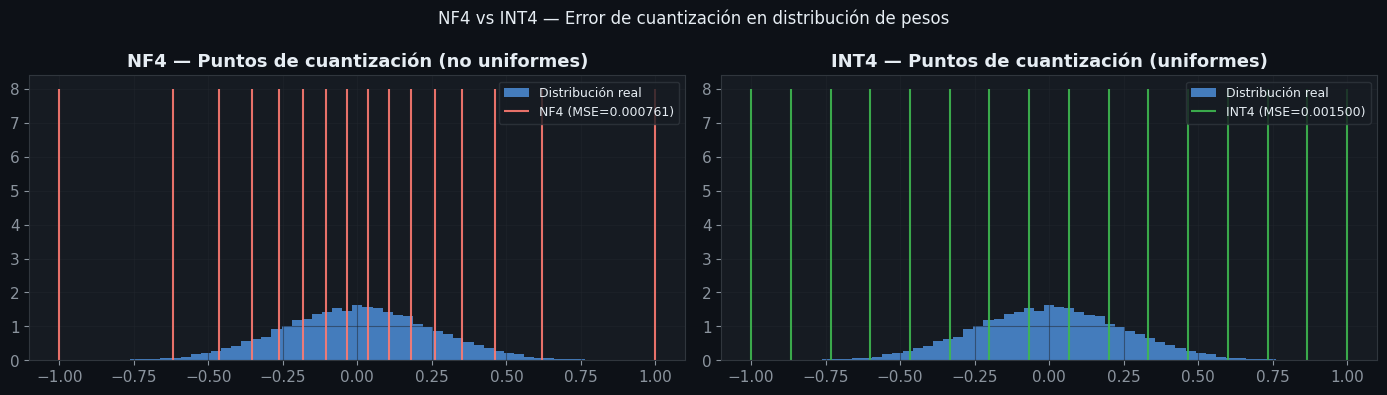

NF4 MSE  = 0.00076142
INT4 MSE = 0.00149992
NF4 reduce el error en 49.2% respecto a INT4


In [7]:
# ============================================================
#  QLoRA — Configuración con transformers + bitsandbytes
# ============================================================

# ── Configuración BitsAndBytes (NF4 + double quantization) ─

QLORA_CONFIG_CODE = '''
from transformers import BitsAndBytesConfig, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
import torch

# ── 1. Configuración de cuantización NF4 ─────────────────
bnb_config = BitsAndBytesConfig(
    load_in_4bit              = True,          # cuantizar a 4-bit
    bnb_4bit_quant_type       = "nf4",         # NormalFloat4 (mejor que INT4)
    bnb_4bit_compute_dtype    = torch.bfloat16, # cómputo en BF16
    bnb_4bit_use_double_quant = True,           # double quantization
)

# ── 2. Cargar modelo en 4-bit ────────────────────────────
model = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-3.1-8B",
    quantization_config = bnb_config,
    device_map          = "auto",
    attn_implementation = "flash_attention_2"  # más eficiente si disponible
)

# ── 3. Preparar para kbit training (necesario antes de LoRA)
model = prepare_model_for_kbit_training(model)

# ── 4. Configuración LoRA ────────────────────────────────
lora_config = LoraConfig(
    r              = 16,           # rank
    lora_alpha     = 16,           # scaling (alpha/r = 1.0)
    target_modules = "all-linear", # aplicar a todas las lineales
    lora_dropout   = 0.05,
    bias           = "none",
    task_type      = "CAUSAL_LM",
    use_dora       = False,         # True para DoRA
)

# ── 5. Aplicar LoRA al modelo cuantizado ─────────────────
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
# trainable params: 41,943,040 || all params: 8,072,425,472 || trainable%: 0.519%
'''

print('── Código QLoRA (referencia) ──')
print(QLORA_CONFIG_CODE)

# ── Simulación de NF4 vs INT4 ─────────────────────────────
# NF4 está optimizado para distribución normal de pesos
# Mostrar que NF4 discretiza mejor la distribución de pesos reales

np.random.seed(42)
pesos_simulados = np.random.normal(0, 0.02, 10000)  # distribución típica de pesos

# NF4: 16 valores uniformemente espaciados en cuantiles de la N(0,1)
from scipy import stats as scipy_stats
nf4_values = scipy_stats.norm.ppf(np.linspace(0.01, 0.99, 16))
nf4_values = nf4_values / np.abs(nf4_values).max()  # normalizar a [-1, 1]

# INT4: 16 valores uniformemente espaciados
int4_values = np.linspace(-1, 1, 16)

def cuantizar(x, grid):
    """Cuantiza x al valor más cercano del grid."""
    return grid[np.argmin(np.abs(x.reshape(-1,1) - grid.reshape(1,-1)), axis=1)]

escala = np.abs(pesos_simulados).max()
pesos_norm = pesos_simulados / escala

err_nf4  = np.mean((pesos_norm - cuantizar(pesos_norm, nf4_values))**2)
err_int4 = np.mean((pesos_norm - cuantizar(pesos_norm, int4_values))**2)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('NF4 vs INT4 — Error de cuantización en distribución de pesos', fontsize=12)

bins = np.linspace(-1, 1, 60)
axes[0].hist(pesos_norm, bins=bins, color=PALETTE[0], alpha=0.7, density=True, label='Distribución real')
axes[0].vlines(nf4_values, 0, 8, color=PALETTE[1], lw=1.5, alpha=0.9, label=f'NF4 (MSE={err_nf4:.6f})')
axes[0].set_title('NF4 — Puntos de cuantización (no uniformes)')
axes[0].legend(fontsize=9);  axes[0].grid(True)

axes[1].hist(pesos_norm, bins=bins, color=PALETTE[0], alpha=0.7, density=True, label='Distribución real')
axes[1].vlines(int4_values, 0, 8, color=PALETTE[2], lw=1.5, alpha=0.9, label=f'INT4 (MSE={err_int4:.6f})')
axes[1].set_title('INT4 — Puntos de cuantización (uniformes)')
axes[1].legend(fontsize=9);  axes[1].grid(True)

plt.tight_layout()
plt.savefig('qlora_nf4.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'NF4 MSE  = {err_nf4:.8f}')
print(f'INT4 MSE = {err_int4:.8f}')
print(f'NF4 reduce el error en {(1-err_nf4/err_int4)*100:.1f}% respecto a INT4')

---
# 6. Variantes de LoRA

| Variante | Innovación clave | Ventaja | Cuándo usarla |
|---|---|---|---|
| **LoRA** | Factorización BA de ΔW | Base de todo | Siempre como baseline |
| **rsLoRA** | Scaling α/√r en lugar de α/r | Más estable con ranks altos | r ≥ 32 |
| **DoRA** | Descompone W en magnitud + dirección | Comportamiento más cercano a full FT | Tareas con shift significativo |
| **AdaLoRA** | Rank adaptativo por capa según importancia | Evita desperdiciar capacidad | Recursos muy limitados |
| **DyLoRA** | Entrena múltiples ranks en paralelo | Un entrenamiento → múltiples configuraciones | Cuando no sabes qué rank usar |
| **PiSSA** | Inicializa A,B desde SVD del peso original | Converge más rápido | Si tienes budget de compute extra al inicio |
| **LoftQ** | Inicializa LoRA minimizando error de cuantización | Mejor calidad en QLoRA | QLoRA con degradación visible |
| **LoRA+** | Learning rates distintos para A y B | +2% rendimiento sin coste extra | Siempre que uses LoRA |
| **VeRA** | Matrices A,B compartidas + vectores individuales | 10x menos parámetros que LoRA | Hardware extremadamente limitado |

In [8]:
# ============================================================
#  VARIANTES DE LORA — Implementaciones clave
# ============================================================

# ── 1. rsLoRA — Rank-Stabilized LoRA ─────────────────────
class rsLoRALayer(nn.Module):
    """
    rsLoRA: scaling = alpha / sqrt(r) en lugar de alpha / r.
    Más estable con ranks altos porque normaliza mejor la magnitud del gradiente.
    """
    def __init__(self, linear: nn.Linear, r: int = 16, alpha: float = 16.0):
        super().__init__()
        self.linear  = linear
        self.scaling = alpha / math.sqrt(r)   # ← diferencia clave vs LoRA
        d_out, d_in  = linear.weight.shape
        self.linear.weight.requires_grad_(False)
        self.lora_A  = nn.Parameter(torch.empty(r, d_in))
        self.lora_B  = nn.Parameter(torch.zeros(d_out, r))
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))

    def forward(self, x):
        return self.linear(x) + self.scaling * (x @ self.lora_A.T @ self.lora_B.T)


# ── 2. DoRA — Weight-Decomposed LoRA ─────────────────────
class DoRALayer(nn.Module):
    """
    DoRA: descompone W = m * (V/||V||) donde m es magnitud y V es dirección.
    LoRA se aplica solo a la dirección; la magnitud se aprende separadamente.
    Reproduce mejor el comportamiento del full fine-tuning.
    """
    def __init__(self, linear: nn.Linear, r: int = 16, alpha: float = 16.0):
        super().__init__()
        self.linear   = linear
        self.scaling  = alpha / r
        d_out, d_in   = linear.weight.shape
        self.linear.weight.requires_grad_(False)

        # Magnitud inicial (norma de cada fila)
        self.magnitude = nn.Parameter(
            linear.weight.norm(p=2, dim=1, keepdim=True).detach()
        )  # entrenable

        self.lora_A = nn.Parameter(torch.empty(r, d_in))
        self.lora_B = nn.Parameter(torch.zeros(d_out, r))
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Dirección actualizada = W_0 + ΔW (contribución LoRA)
        delta_W  = self.scaling * (self.lora_B @ self.lora_A)
        W_updated = self.linear.weight + delta_W
        # Normalizar dirección y escalar por magnitud aprendida
        W_norm = W_updated.norm(p=2, dim=1, keepdim=True).clamp(min=1e-6)
        W_final = self.magnitude * (W_updated / W_norm)
        return F.linear(x, W_final, self.linear.bias)


# ── 3. Comparativa de comportamiento (toy example) ───────

torch.manual_seed(42)
d = 64
linear_base = nn.Linear(d, d, bias=False)

# Copias para cada variante
lora_std = LoRALayer(copy.deepcopy(linear_base), r=8, alpha=8.0)
lora_rs  = rsLoRALayer(copy.deepcopy(linear_base), r=8, alpha=8.0)
lora_dor = DoRALayer(copy.deepcopy(linear_base), r=8, alpha=8.0)

# Contar parámetros entrenables
def count_trainable(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print('── Comparativa de variantes LoRA (d=64, r=8) ──')
print(f'LoRA estándar : {count_trainable(lora_std):>8,} parámetros entrenables  | scaling={lora_std.scaling:.4f}')
print(f'rsLoRA : {count_trainable(lora_rs):>8,} parámetros entrenables  | scaling={lora_rs.scaling:.4f}')
print(f'DoRA: {count_trainable(lora_dor):>8,} parámetros entrenables  | (+magnitud vector)')

# ── 4. Configuración PEFT para DoRA con HuggingFace ──────
DORA_CONFIG_CODE = '''
from peft import LoraConfig, get_peft_model

# DoRA: solo añadir use_dora=True a la config de LoRA
config = LoraConfig(
    r              = 16,
    lora_alpha     = 16,
    target_modules = "all-linear",
    use_dora       = True,    # ← activa DoRA
    use_rslora     = True,    # ← activa rsLoRA scaling (alpha/sqrt(r))
    lora_dropout   = 0.05,
    task_type      = "CAUSAL_LM",
    init_lora_weights = "pissa",  # PiSSA initialization (alternativa: "loftq")
)

# QDoRA: QLoRA + DoRA (la combinación recomendada en 2025)
# Solo combinar bnb_config del QLoRA con use_dora=True
'''

print('\n── Configuración DoRA + rsLoRA + PiSSA (HuggingFace PEFT) ──')
print(DORA_CONFIG_CODE)

── Comparativa de variantes LoRA (d=64, r=8) ──
LoRA estándar :    1,024 parámetros entrenables  | scaling=1.0000
rsLoRA :    1,024 parámetros entrenables  | scaling=2.8284
DoRA:    1,088 parámetros entrenables  | (+magnitud vector)

── Configuración DoRA + rsLoRA + PiSSA (HuggingFace PEFT) ──

from peft import LoraConfig, get_peft_model

# DoRA: solo añadir use_dora=True a la config de LoRA
config = LoraConfig(
    r              = 16,
    lora_alpha     = 16,
    target_modules = "all-linear",
    use_dora       = True,    # ← activa DoRA
    use_rslora     = True,    # ← activa rsLoRA scaling (alpha/sqrt(r))
    lora_dropout   = 0.05,
    task_type      = "CAUSAL_LM",
    init_lora_weights = "pissa",  # PiSSA initialization (alternativa: "loftq")
)

# QDoRA: QLoRA + DoRA (la combinación recomendada en 2025)
# Solo combinar bnb_config del QLoRA con use_dora=True



---
# 7. Otras Técnicas PEFT

LoRA no es la única familia de PEFT. Hay otras técnicas con casos de uso específicos:

| Técnica | Parámetros entrenables | Cómo funciona | Mejor para |
|---|---|---|---|
| **Prefix Tuning** | ~0.1% | Añade tokens virtuales al inicio del contexto | Generación condicional |
| **Prompt Tuning** | ~0.001% | Solo aprende el embedding de un prompt prefix | Clasificación con modelo muy grande |
| **P-Tuning v2** | ~0.1% | Prefix en cada capa (no solo la primera) | NLU tasks |
| **IA³** | ~0.01% | Escala activaciones con vectores aprendidos | Muy pocos parámetros |
| **Adapter Tuning** | ~1-5% | Inserta pequeños módulos FFN entre capas | Multitarea |
| **(IA)³** | ~0.01% | Infused Adapter by Inhibiting and Amplifying | Few-shot extremo |

In [9]:
# ============================================================
#  OTRAS TÉCNICAS PEFT — Implementaciones
# ============================================================

# ── 1. Prefix Tuning desde cero ───────────────────────────
class PrefixTuning(nn.Module):
    """
    Prefix Tuning: añade n_prefix tokens virtuales entrenables
    al inicio de la secuencia de Keys y Values en cada capa de atención.
    El modelo base está completamente congelado.
    """
    def __init__(self, d_model: int, n_heads: int,
                  n_prefix: int = 10, n_layers: int = 12):
        super().__init__()
        self.n_prefix = n_prefix
        self.d_model = d_model
        d_head = d_model // n_heads
        # Prefijos para K y V en cada capa
        # Forma: (n_layers, 2, n_heads, n_prefix, d_head)
        self.prefix_kv = nn.Parameter(
            torch.randn(n_layers, 2, n_heads, n_prefix, d_head) * 0.01
        )

    def get_prefix(self, layer_idx: int):
        """Devuelve (prefix_K, prefix_V) para la capa dada."""
        return self.prefix_kv[layer_idx, 0], self.prefix_kv[layer_idx, 1]

    def n_params(self) -> int:
        return self.prefix_kv.numel()


# ── 2. IA³ — Infused Adapter by Inhibiting and Amplifying ─
class IA3Layer(nn.Module):
    """
    IA³: introduce vectores de escala l_k, l_v, l_ff aprendidos
    que modulan keys, values y la activación de la FFN.
    Requiere un orden de magnitud menos parámetros que LoRA.
    """
    def __init__(self, d_model: int, d_ff: int):
        super().__init__()
        # Vectores de escala (inicializados a 1 → sin efecto inicial)
        self.l_k  = nn.Parameter(torch.ones(d_model))
        self.l_v  = nn.Parameter(torch.ones(d_model))
        self.l_ff = nn.Parameter(torch.ones(d_ff))

    def scale_keys(self, k: torch.Tensor) -> torch.Tensor:
        return k * self.l_k

    def scale_values(self, v: torch.Tensor) -> torch.Tensor:
        return v * self.l_v

    def scale_ff(self, x: torch.Tensor) -> torch.Tensor:
        return x * self.l_ff

    def n_params(self) -> int:
        return self.l_k.numel() + self.l_v.numel() + self.l_ff.numel()


# ── Comparativa de eficiencia de parámetros ───────────────
d_model = 4096
n_heads = 32
n_layers = 32
d_ff = 11008  # Llama-2 7B
n_prefix = 10
r_lora = 16

# Parámetros base de un transformer bloque
params_base_layer = (4 * d_model**2 +    # Q, K, V, O projections
                     2 * d_model * d_ff)  # FFN up + down
params_base_total = params_base_layer * n_layers

# PEFT comparativa
params_lora  = n_layers * 4 * 2 * r_lora * d_model  # Q,K,V,O en cada capa
params_prefix = PrefixTuning(d_model, n_heads, n_prefix, n_layers).n_params()
params_ia3 = n_layers * IA3Layer(d_model, d_ff).n_params()
params_prompt = n_prefix * d_model  # solo el embedding del prefix

tecnicas = {
    'LoRA (r=16)': params_lora,
    'Prefix Tuning': params_prefix,
    'IA³': params_ia3,
    'Prompt Tuning': params_prompt,
}

print('── Comparativa de parámetros entrenables (modelo 7B aprox) ──')
print(f'  Parámetros base: {params_base_total/1e9:.2f}B')
print()
for nombre, n in tecnicas.items():
    pct = n / params_base_total * 100
    bar = '█' * int(pct * 2) + '░' * max(0, 20 - int(pct * 2))
    print(f'  {nombre:<20}: {n/1e6:>7.2f}M ({pct:5.3f}%)  {bar}')

── Comparativa de parámetros entrenables (modelo 7B aprox) ──
  Parámetros base: 5.03B

  LoRA (r=16)         :   16.78M (0.333%)  ░░░░░░░░░░░░░░░░░░░░
  Prefix Tuning       :    2.62M (0.052%)  ░░░░░░░░░░░░░░░░░░░░
  IA³                 :    0.61M (0.012%)  ░░░░░░░░░░░░░░░░░░░░
  Prompt Tuning       :    0.04M (0.001%)  ░░░░░░░░░░░░░░░░░░░░


---
# 8. Supervised Fine-Tuning (SFT) con TRL

El SFT es el primer paso del pipeline de alineación: enseñar al modelo a seguir instrucciones en el formato correcto.

In [10]:
# ============================================================
#  SFT CON TRL — Código de referencia completo
# ============================================================

SFT_CODE = '''
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments
from peft import LoraConfig
from trl import SFTTrainer, SFTConfig, DataCollatorForCompletionOnlyLM

# ── 1. Modelo y tokenizer ────────────────────────────────
model_name  = "meta-llama/Llama-3.1-8B"
tokenizer   = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"  # importante para SFT

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype       = torch.bfloat16,
    device_map        = "auto",
    attn_implementation = "flash_attention_2",
)

# ── 2. Dataset ───────────────────────────────────────────
dataset = load_dataset("trl-lib/ultrachat_200k", split="train_sft")

# ── 3. Función de formateo al chat template del modelo ───
def formatting_func(example):
    return tokenizer.apply_chat_template(
        example["messages"],
        tokenize=False,
        add_generation_prompt=False
    )

# ── 4. LoRA config ───────────────────────────────────────
peft_config = LoraConfig(
    r              = 16,
    lora_alpha     = 16,
    lora_dropout   = 0.05,
    target_modules = "all-linear",
    task_type      = "CAUSAL_LM",
    use_dora       = True,
)

# ── 5. Training config ───────────────────────────────────
training_args = SFTConfig(
    output_dir              = "./sft_output",
    num_train_epochs        = 3,
    per_device_train_batch_size = 2,
    gradient_accumulation_steps = 8,   # effective batch = 16
    learning_rate           = 2e-4,
    lr_scheduler_type       = "cosine",
    warmup_ratio            = 0.05,
    bf16                    = True,
    logging_steps           = 25,
    save_steps              = 500,
    max_seq_length          = 2048,
    packing                 = True,    # packing mejora throughput
    report_to               = "wandb",
)

# ── 6. Trainer ────────────────────────────────────────────
trainer = SFTTrainer(
    model             = model,
    args              = training_args,
    train_dataset     = dataset,
    formatting_func   = formatting_func,
    peft_config       = peft_config,
)

# ── 7. Entrenar ───────────────────────────────────────────
trainer.train()
trainer.save_model("./sft_final")
'''

print('── SFT con TRL — Código de referencia ──')
print(SFT_CODE)

# ── Packing: qué es y por qué importa ────────────────────
print('── Packing: eficiencia de tokens ──')
print()

# Simulación del impacto del packing
np.random.seed(42)
longitudes = np.random.exponential(scale=300, size=100).astype(int).clip(50, 2048)
max_len = 2048

# Sin packing: cada ejemplo en su propio batch (mucho padding)
tokens_sin_packing = len(longitudes) * max_len
tokens_reales      = longitudes.sum()
eficiencia_sin     = tokens_reales / tokens_sin_packing

# Con packing: rellenar secuencias hasta max_len
bins_packed  = []
bin_actual   = 0
for l in sorted(longitudes, reverse=True):
    if bin_actual + l <= max_len:
        bin_actual += l
    else:
        bins_packed.append(bin_actual)
        bin_actual = l
bins_packed.append(bin_actual)
tokens_con_packing = len(bins_packed) * max_len
eficiencia_con     = tokens_reales / tokens_con_packing

print(f'Tokens reales : {tokens_reales:>10,}')
print(f'Sin packing (steps) : {len(longitudes):>10} steps → eficiencia {eficiencia_sin:.1%}')
print(f'Con packing (steps) : {len(bins_packed):>10} steps → eficiencia {eficiencia_con:.1%}')
print(f'Speedup packing     : {len(longitudes)/len(bins_packed):.1f}x menos pasos')

── SFT con TRL — Código de referencia ──

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments
from peft import LoraConfig
from trl import SFTTrainer, SFTConfig, DataCollatorForCompletionOnlyLM

# ── 1. Modelo y tokenizer ────────────────────────────────
model_name  = "meta-llama/Llama-3.1-8B"
tokenizer   = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"  # importante para SFT

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype       = torch.bfloat16,
    device_map        = "auto",
    attn_implementation = "flash_attention_2",
)

# ── 2. Dataset ───────────────────────────────────────────
dataset = load_dataset("trl-lib/ultrachat_200k", split="train_sft")

# ── 3. Función de formateo al chat template del modelo ───
def formatting_func(example):
    return tokenizer.apply_chat_template(
        example["messages"],
        tokeniz

---
# 9. RLHF — Reinforcement Learning from Human Feedback

RLHF alinea el LLM con preferencias humanas en 3 fases:

**Fase 1 — SFT**: Fine-tune supervisado sobre demostraciones de alta calidad.

**Fase 2 — Reward Model**: Entrenar un modelo de recompensa $r_\phi(x, y)$ con pares de preferencias $(y_w \succ y_l | x)$:

$$\mathcal{L}_{RM} = -\mathbb{E}_{(x, y_w, y_l)} \left[ \log \sigma(r_\phi(x, y_w) - r_\phi(x, y_l)) \right]$$

**Fase 3 — RL con PPO**: Optimizar el LLM con la señal del reward model más una penalización KL frente al modelo SFT:

$$\max_{\pi_\theta} \mathbb{E}_{x \sim D, y \sim \pi_\theta} \left[ r_\phi(x, y) - \beta \underbrace{D_{KL}[\pi_\theta(y|x) \| \pi_{ref}(y|x)]}_\text{penalización KL} \right]$$

El término KL previene que el modelo se aleje demasiado del SFT (reward hacking).

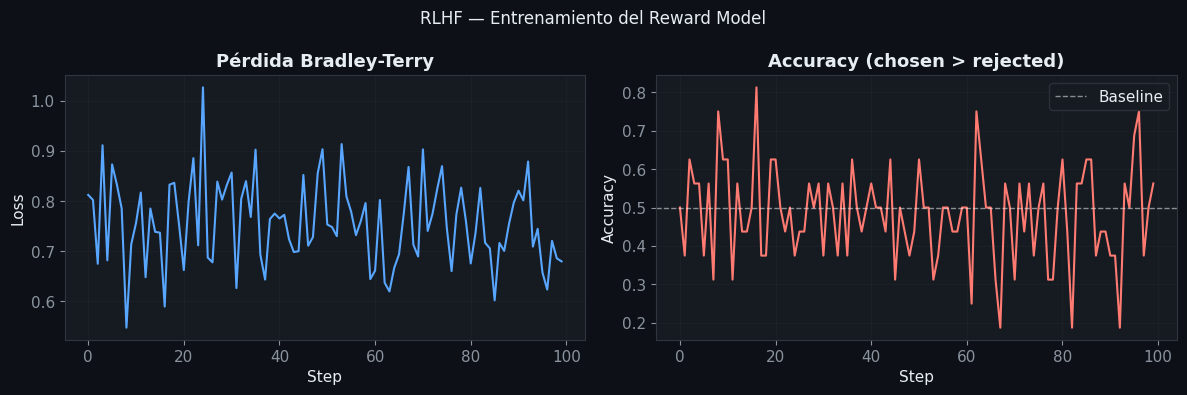

  Accuracy final del Reward Model: 56.2%


In [11]:
# ============================================================
#  RLHF — Reward Model y visualización del pipeline
# ============================================================

# ── Reward Model simplificado ─────────────────────────────
class RewardModel(nn.Module):
    """
    Reward model para RLHF: toma (prompt + respuesta) y devuelve un escalar.
    En la práctica se parte de un LLM SFT y se reemplaza la cabeza de LM
    por una capa lineal que produce un único valor de recompensa.
    """
    def __init__(self, d_model: int = 256, vocab_size: int = 1000):
        super().__init__()
        # Simula el backbone transformer
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model, nhead=4, batch_first=True),
            num_layers=2
        )
        # Cabeza de recompensa: en lugar del head LM, una lineal → escalar
        self.reward_head = nn.Linear(d_model, 1)

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        x = self.embedding(input_ids)
        x = self.transformer(x)
        # Usar el token [EOS] como representación de la secuencia completa
        reward = self.reward_head(x[:, -1, :]).squeeze(-1)
        return reward


def loss_reward_model(r_chosen: torch.Tensor, r_rejected: torch.Tensor) -> torch.Tensor:
    """
    Bradley-Terry preference loss:
    L = -log(σ(r_chosen - r_rejected))
    """
    return -F.logsigmoid(r_chosen - r_rejected).mean()


# ── Simulación de entrenamiento del Reward Model ──────────
torch.manual_seed(42)
rm = RewardModel()
optim = torch.optim.AdamW(rm.parameters(), lr=1e-4)

losses= []
acc_hist = []

for step in range(100):
    # Simular batch de pares (chosen, rejected)
    bs = 16
    seq_c = torch.randint(0, 1000, (bs, 20))  # respuestas preferidas
    seq_r = torch.randint(0, 1000, (bs, 20))  # respuestas rechazadas

    r_c = rm(seq_c)
    r_r = rm(seq_r)
    loss = loss_reward_model(r_c, r_r)

    optim.zero_grad()
    loss.backward()
    optim.step()

    acc = (r_c > r_r).float().mean().item()
    losses.append(loss.item())
    acc_hist.append(acc)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('RLHF — Entrenamiento del Reward Model', fontsize=12)

axes[0].plot(losses, color=PALETTE[0])
axes[0].set_title('Pérdida Bradley-Terry')
axes[0].set_xlabel('Step'); axes[0].set_ylabel('Loss'); axes[0].grid(True)

axes[1].plot(acc_hist, color=PALETTE[1])
axes[1].axhline(0.5, color='white', ls='--', lw=1, alpha=0.5, label='Baseline')
axes[1].set_title('Accuracy (chosen > rejected)')
axes[1].set_xlabel('Step'); axes[1].set_ylabel('Accuracy'); axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.savefig('rlhf_reward_model.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'  Accuracy final del Reward Model: {acc_hist[-1]:.1%}')

---
# 10. DPO — Direct Preference Optimization

DPO elimina el reward model explícito y el PPO. Muestra que el problema de RLHF puede resolverse directamente como una clasificación sobre pares de preferencia.

**Insight clave**: el reward óptimo para el problema RLHF tiene una forma cerrada en función de la política:

$$r^*(x, y) = \beta \log \frac{\pi^*(y|x)}{\pi_{ref}(y|x)} + \beta \log Z(x)$$

Sustituyendo en la pérdida Bradley-Terry del reward model:

$$\mathcal{L}_{DPO}(\pi_\theta) = -\mathbb{E}_{(x, y_w, y_l)} \left[ \log \sigma \left( \beta \log \frac{\pi_\theta(y_w|x)}{\pi_{ref}(y_w|x)} - \beta \log \frac{\pi_\theta(y_l|x)}{\pi_{ref}(y_l|x)} \right) \right]$$

No se necesita reward model, no se necesita PPO. Solo una política de referencia ($\pi_{ref}$, el modelo SFT) y pares de preferencia.

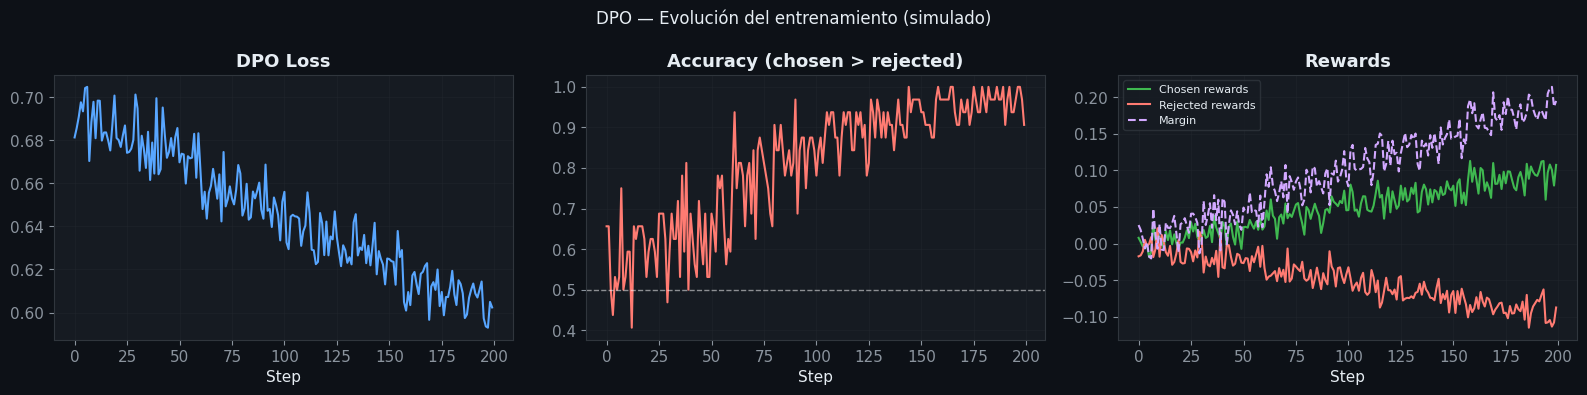

── DPO con TRL ──

from trl import DPOTrainer, DPOConfig

dpo_config = DPOConfig(
    output_dir          = "./dpo_output",
    beta                = 0.1,             # temperatura KL
    loss_type           = "sigmoid",       # DPO estándar
    num_train_epochs    = 3,
    per_device_train_batch_size = 2,
    gradient_accumulation_steps = 4,
    learning_rate       = 5e-7,            # LR más bajo que SFT
    bf16                = True,
    max_length          = 1536,
    max_prompt_length   = 768,
    logging_steps       = 10,
)

trainer = DPOTrainer(
    model           = model,               # modelo a afinar
    ref_model       = ref_model,           # modelo de referencia (SFT, congelado)
    args            = dpo_config,
    train_dataset   = dataset,             # columnas: prompt, chosen, rejected
    processing_class = tokenizer,
    peft_config     = peft_config,
)
trainer.train()



In [12]:
# ============================================================
#  DPO — Direct Preference Optimization desde cero
# ============================================================

def dpo_loss(pi_logprob_chosen:   torch.Tensor,
              pi_logprob_rejected: torch.Tensor,
              ref_logprob_chosen:  torch.Tensor,
              ref_logprob_rejected: torch.Tensor,
              beta: float = 0.1) -> tuple[torch.Tensor, dict]:
    """
    Pérdida DPO.

    Parámetros
    ----------
    pi_logprob_*  : log-probabilidades del modelo que se entrena
    ref_logprob_* : log-probabilidades del modelo de referencia (congelado)
    beta          : temperatura KL (0.1–0.5 típico)

    Retorna
    -------
    loss, métricas
    """
    # Ratios log π / π_ref
    log_ratio_w = pi_logprob_chosen   - ref_logprob_chosen
    log_ratio_l = pi_logprob_rejected - ref_logprob_rejected

    # DPO loss = -log σ(β * (log_ratio_w - log_ratio_l))
    logits = beta * (log_ratio_w - log_ratio_l)
    loss = -F.logsigmoid(logits).mean()

    # Métricas útiles para monitorizar el entrenamiento
    chosen_rewards = (beta * log_ratio_w).detach()
    rejected_rewards = (beta * log_ratio_l).detach()
    accuracy = (chosen_rewards > rejected_rewards).float().mean()
    reward_margin = (chosen_rewards - rejected_rewards).mean()

    metricas = {
        'loss': loss.item(),
        'accuracy': accuracy.item(),
        'reward_margin': reward_margin.item(),
        'chosen_rewards':chosen_rewards.mean().item(),
        'rejected_rewards': rejected_rewards.mean().item(),
    }
    return loss, metricas


# ── Simulación de entrenamiento DPO ──────────────────────
torch.manual_seed(42)
hist = {'loss': [], 'accuracy': [], 'reward_margin': [],
        'chosen_rewards': [], 'rejected_rewards': []}

# Inicializar con distribuciones que se vayan separando con el entrenamiento
sep = 0.0  # separación creciente (simula mejora del modelo)

for step in range(200):
    bs = 32
    sep += 0.005  # el modelo aprende a separar chosen de rejected

    # Log-probabilidades simuladas (chosen > rejected implica preferencia)
    pi_logp_c  = torch.randn(bs) * 0.5 + sep
    pi_logp_r  = torch.randn(bs) * 0.5 - sep
    ref_logp_c = torch.randn(bs) * 0.5
    ref_logp_r = torch.randn(bs) * 0.5

    loss, m = dpo_loss(pi_logp_c, pi_logp_r, ref_logp_c, ref_logp_r, beta=0.1)
    for k, v in m.items():
        hist[k].append(v)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('DPO — Evolución del entrenamiento (simulado)', fontsize=12)

axes[0].plot(hist['loss'], color=PALETTE[0])
axes[0].set_title('DPO Loss'); axes[0].set_xlabel('Step'); axes[0].grid(True)

axes[1].plot(hist['accuracy'], color=PALETTE[1])
axes[1].axhline(0.5, color='white', ls='--', lw=1, alpha=0.5)
axes[1].set_title('Accuracy (chosen > rejected)'); axes[1].set_xlabel('Step'); axes[1].grid(True)

axes[2].plot(hist['chosen_rewards'],   color=PALETTE[2], label='Chosen rewards')
axes[2].plot(hist['rejected_rewards'], color=PALETTE[1], label='Rejected rewards')
axes[2].plot(hist['reward_margin'],    color=PALETTE[3], label='Margin', ls='--')
axes[2].set_title('Rewards'); axes[2].set_xlabel('Step'); axes[2].grid(True)
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('dpo_training.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# ── Código DPO con TRL ────────────────────────────────────
DPO_TRL_CODE = '''
from trl import DPOTrainer, DPOConfig

dpo_config = DPOConfig(
    output_dir          = "./dpo_output",
    beta                = 0.1,             # temperatura KL
    loss_type           = "sigmoid",       # DPO estándar
    num_train_epochs    = 3,
    per_device_train_batch_size = 2,
    gradient_accumulation_steps = 4,
    learning_rate       = 5e-7,            # LR más bajo que SFT
    bf16                = True,
    max_length          = 1536,
    max_prompt_length   = 768,
    logging_steps       = 10,
)

trainer = DPOTrainer(
    model           = model,               # modelo a afinar
    ref_model       = ref_model,           # modelo de referencia (SFT, congelado)
    args            = dpo_config,
    train_dataset   = dataset,             # columnas: prompt, chosen, rejected
    processing_class = tokenizer,
    peft_config     = peft_config,
)
trainer.train()
'''
print('── DPO con TRL ──')
print(DPO_TRL_CODE)

---
# 11. Variantes de Alineación — ORPO, SimPO, KTO, GRPO

| Método | Vs DPO | Innovación | Formato de datos |
|---|---|---|---|
| **DPO** | Baseline | Elimina PPO, usa pares preferencia | `(prompt, chosen, rejected)` |
| **ORPO** | Sin ref model | Combina SFT + preference en una sola pérdida | `(prompt, chosen, rejected)` |
| **SimPO** | Sin ref model | Normalización por longitud + margen target | `(prompt, chosen, rejected)` |
| **KTO** | Sin pares | Solo necesita respuestas + señal buena/mala | `(prompt, completion, label)` |
| **GRPO** | RL completo | Optimiza grupo de respuestas contra sí mismas | Samples del propio modelo |
| **IPO** | Sin colapso | Regularización que previene colapso en DPO | `(prompt, chosen, rejected)` |
| **CPO** | Eficiente | Chain of Preference, sin ref model | `(prompt, chosen, rejected)` |

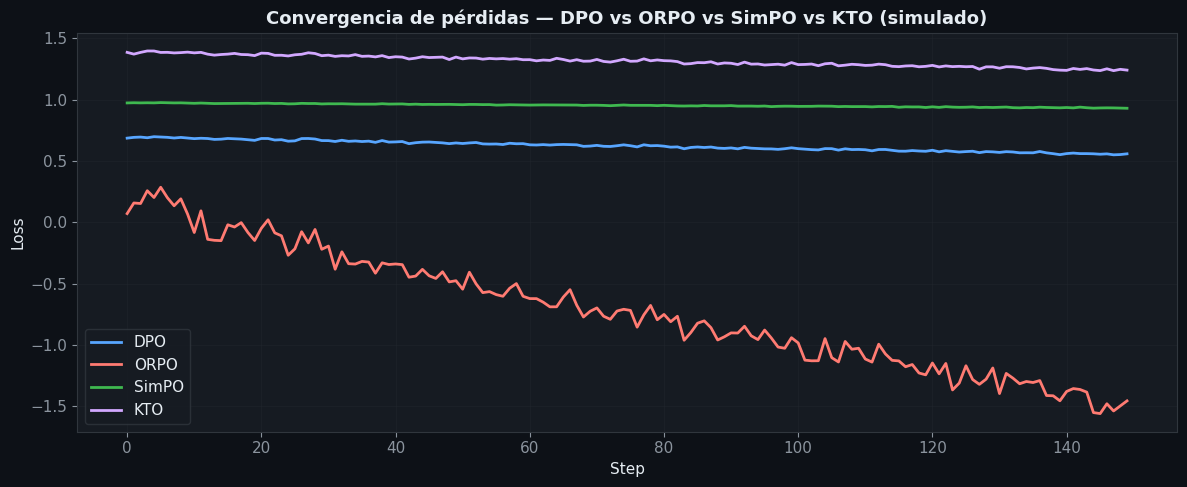

── GRPO con TRL ──

# GRPO (Group Relative Policy Optimization) — usado en DeepSeek-R1
# Genera G respuestas por prompt, computa recompensas,
# normaliza dentro del grupo y optimiza el policy gradient

from trl import GRPOTrainer, GRPOConfig

def reward_fn(completions, prompts=None, **kwargs):
    """Función de recompensa personalizada (ej: verificar respuesta correcta)."""
    rewards = []
    for completion in completions:
        # Ejemplo: recompensa por formato correcto
        reward = 1.0 if "<answer>" in completion else 0.0
        rewards.append(reward)
    return rewards

grpo_config = GRPOConfig(
    output_dir         = "./grpo_output",
    num_generations    = 8,      # G: respuestas por prompt
    max_new_tokens     = 512,
    learning_rate      = 1e-6,
    beta               = 0.01,   # penalización KL
    num_train_epochs   = 1,
    per_device_train_batch_size = 1,
    gradient_accumulation_steps = 8,
)

trainer = GRPOTrainer(
    model         = model,
    args        

In [13]:
# ============================================================
#  VARIANTES DE ALINEACIÓN — Pérdidas desde cero
# ============================================================

# ── ORPO — Odds Ratio Preference Optimization ─────────────
def orpo_loss(logprob_chosen: torch.Tensor,
               logprob_rejected: torch.Tensor,
               logprob_chosen_sft: torch.Tensor,   # log-prob promedio para NLL
               beta: float = 0.1) -> tuple:
    """
    ORPO: combina SFT (NLL sobre chosen) + preferencia (odds ratio) en una sola pérdida.
    No necesita modelo de referencia separado — el SFT está implícito en la pérdida.

    L_ORPO = L_SFT + β * L_OR
    L_OR   = -log σ(log(odds_ratio(chosen) / odds_ratio(rejected)))
    """
    # SFT loss: NLL sobre las respuestas preferidas
    l_sft = -logprob_chosen_sft.mean()

    # Odds ratio
    # odds(y|x) = P(y|x) / (1 - P(y|x)) ≈ exp(logprob) para secuencias largas
    log_odds_chosen   = logprob_chosen   - torch.log1p(-logprob_chosen.exp().clamp(0, 0.9999))
    log_odds_rejected = logprob_rejected - torch.log1p(-logprob_rejected.exp().clamp(0, 0.9999))

    l_or = -F.logsigmoid(log_odds_chosen - log_odds_rejected).mean()

    loss = l_sft + beta * l_or
    return loss, {'l_sft': l_sft.item(), 'l_or': l_or.item()}


# ── SimPO — Simple Preference Optimization ────────────────
def simpo_loss(logprob_chosen: torch.Tensor,
                logprob_rejected: torch.Tensor,
                len_chosen: torch.Tensor,
                len_rejected: torch.Tensor,
                beta: float = 2.5,
                gamma: float = 0.5) -> torch.Tensor:
    """
    SimPO: dos diferencias clave vs DPO:
    1. Normaliza log-probs por longitud (evita sesgo hacia respuestas largas)
    2. Introduce margen γ > 0 (separación mínima entre chosen y rejected)

    No necesita modelo de referencia.
    """
    # Normalización por longitud
    avg_logprob_chosen   = logprob_chosen   / len_chosen
    avg_logprob_rejected = logprob_rejected / len_rejected

    # SimPO loss con margen
    logits = beta * (avg_logprob_chosen - avg_logprob_rejected) - gamma
    return -F.logsigmoid(logits).mean()


# ── KTO — Kahneman-Tversky Optimization ───────────────────
def kto_loss(logprob: torch.Tensor,
              ref_logprob: torch.Tensor,
              label: torch.Tensor,  # 1 = buena respuesta, 0 = mala
              beta: float = 0.1,
              desirable_weight: float = 1.0,
              undesirable_weight: float = 1.0) -> torch.Tensor:
    """
    KTO: inspirado en la Teoría Prospectiva de Kahneman-Tversky.
    No necesita pares — solo saber si cada respuesta es buena o mala.
    Aplica penalizaciones asimétricas (las malas pesan más que las buenas).
    """
    log_ratio = logprob - ref_logprob   # implicitly: log π / π_ref

    # Valor KTO asimétrico
    kl_term = log_ratio.detach().mean()  # usado como z-score de referencia

    loss_desirable   = -F.logsigmoid(beta * (log_ratio - kl_term))
    loss_undesirable = -F.logsigmoid(-beta * (log_ratio - kl_term))

    # Combinar con pesos asimétricos
    is_good = label.bool()
    loss = (
        desirable_weight   * loss_desirable[is_good].mean() +
        undesirable_weight * loss_undesirable[~is_good].mean()
    )
    return loss


# ── Comparativa visual ────────────────────────────────────
torch.manual_seed(42)
pasos = 150
hist_metodos = {m: [] for m in ['DPO', 'ORPO', 'SimPO', 'KTO']}

for step in range(pasos):
    bs   = 32
    sep  = step / pasos * 1.5  # separación creciente simulada

    logp_c = torch.randn(bs) * 0.3 + sep
    logp_r = torch.randn(bs) * 0.3 - sep
    ref_c = torch.randn(bs) * 0.3
    ref_r = torch.randn(bs) * 0.3

    l_dpo, _ = dpo_loss(logp_c, logp_r, ref_c, ref_r)
    l_orpo, _ = orpo_loss(logp_c, logp_r, logp_c)
    l_simpo   = simpo_loss(logp_c, logp_r,
                            torch.randint(50,200,(bs,)).float(),
                            torch.randint(50,200,(bs,)).float())
    labels = torch.cat([torch.ones(bs//2), torch.zeros(bs//2)])
    logp_mix = torch.cat([logp_c[:bs//2], logp_r[:bs//2]])
    ref_mix = torch.cat([ref_c[:bs//2],  ref_r[:bs//2]])
    l_kto = kto_loss(logp_mix, ref_mix, labels)

    hist_metodos['DPO'].append(l_dpo.item())
    hist_metodos['ORPO'].append(l_orpo.item())
    hist_metodos['SimPO'].append(l_simpo.item())
    hist_metodos['KTO'].append(l_kto.item())

fig, ax = plt.subplots(figsize=(12, 5))
for (nombre, hist), color in zip(hist_metodos.items(), PALETTE[:4]):
    ax.plot(hist, color=color, lw=2, label=nombre)
ax.set_title('Convergencia de pérdidas — DPO vs ORPO vs SimPO vs KTO (simulado)')
ax.set_xlabel('Step'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.savefig('alignment_losses.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# ── GRPO — código de referencia ──────────────────────────
GRPO_CODE = '''
# GRPO (Group Relative Policy Optimization) — usado en DeepSeek-R1
# Genera G respuestas por prompt, computa recompensas,
# normaliza dentro del grupo y optimiza el policy gradient

from trl import GRPOTrainer, GRPOConfig

def reward_fn(completions, prompts=None, **kwargs):
    """Función de recompensa personalizada (ej: verificar respuesta correcta)."""
    rewards = []
    for completion in completions:
        # Ejemplo: recompensa por formato correcto
        reward = 1.0 if "<answer>" in completion else 0.0
        rewards.append(reward)
    return rewards

grpo_config = GRPOConfig(
    output_dir         = "./grpo_output",
    num_generations    = 8,      # G: respuestas por prompt
    max_new_tokens     = 512,
    learning_rate      = 1e-6,
    beta               = 0.01,   # penalización KL
    num_train_epochs   = 1,
    per_device_train_batch_size = 1,
    gradient_accumulation_steps = 8,
)

trainer = GRPOTrainer(
    model         = model,
    args          = grpo_config,
    reward_funcs  = reward_fn,
    train_dataset = dataset,
    peft_config   = peft_config,
)
trainer.train()
'''
print('── GRPO con TRL ──')
print(GRPO_CODE)

---
# 12. Evaluación de Modelos Fine-Tuneados

Un modelo bien entrenado no es solo uno con baja pérdida de entrenamiento. Necesitas medir:
1. **Task performance**: ¿mejora en la tarea objetivo?
2. **General capabilities**: ¿no olvidó el conocimiento base?
3. **Alignment**: ¿sigue instrucciones y es seguro?
4. **Regression**: ¿empeoró en algo que antes hacía bien?

In [14]:
# ============================================================
#  EVALUACIÓN — Métricas y herramientas
# ============================================================

# ── 1. Perplexity ─────────────────────────────────────────
def calcular_perplexity(logits: torch.Tensor,
                          labels: torch.Tensor) -> float:
    """
    Perplexity = exp(NLL promedio) — mide qué tan sorprendente es el texto.
    Menor perplexity = mejor modelo de lenguaje.
    NUNCA comparar perplexity entre modelos con tokenizadores distintos.
    """
    shift_logits = logits[..., :-1, :].contiguous()
    shift_labels = labels[..., 1:].contiguous()
    loss = F.cross_entropy(
        shift_logits.view(-1, shift_logits.size(-1)),
        shift_labels.view(-1),
        ignore_index=-100
    )
    return math.exp(loss.item())


# ── 2. Métricas de generación ─────────────────────────────
def calcular_metricas_texto(predicciones: list[str],
                              referencias:  list[str]) -> dict:
    """Calcula métricas de evaluación para texto generado."""

    # BLEU-1 simplificado (sin NLTK)
    def bleu_1(pred: str, ref: str) -> float:
        pred_tokens = set(pred.lower().split())
        ref_tokens  = set(ref.lower().split())
        if not pred_tokens:
            return 0.0
        return len(pred_tokens & ref_tokens) / len(pred_tokens)

    # ROUGE-L simplificado (LCS)
    def lcs_length(a: list, b: list) -> int:
        m, n = len(a), len(b)
        dp = [[0]*(n+1) for _ in range(m+1)]
        for i in range(1, m+1):
            for j in range(1, n+1):
                if a[i-1] == b[j-1]:
                    dp[i][j] = dp[i-1][j-1] + 1
                else:
                    dp[i][j] = max(dp[i-1][j], dp[i][j-1])
        return dp[m][n]

    def rouge_l(pred: str, ref: str) -> float:
        p = pred.lower().split()
        r = ref.lower().split()
        if not p or not r:
            return 0.0
        lcs = lcs_length(p, r)
        precision = lcs / len(p)
        recall = lcs / len(r)
        if precision + recall == 0:
            return 0.0
        return 2 * precision * recall / (precision + recall)

    bleus  = [bleu_1(p, r) for p, r in zip(predicciones, referencias)]
    rouges = [rouge_l(p, r) for p, r in zip(predicciones, referencias)]

    return {
        'BLEU-1':  np.mean(bleus),
        'ROUGE-L': np.mean(rouges),
        'longitud_media': np.mean([len(p.split()) for p in predicciones])
    }


# ── Demo ──────────────────────────────────────────────────
preds = [
    'El fine-tuning adapta modelos preentrenados a tareas específicas mediante entrenamiento adicional.',
    'LoRA reduce el número de parámetros entrenables usando matrices de bajo rango.',
    'DPO optimiza directamente las preferencias sin necesitar un reward model.',
]
refs = [
    'El fine-tuning es el proceso de adaptar un modelo preentrenado a una tarea nueva.',
    'LoRA es una técnica de fine-tuning eficiente que usa factorización de bajo rango.',
    'DPO es una alternativa a RLHF que no requiere un modelo de recompensa separado.',
]

metricas = calcular_metricas_texto(preds, refs)
print('── Métricas de evaluación ──')
for k, v in metricas.items():
    print(f'  {k}: {v:.4f}')

# ── 3. Benchmarks estándar para LLMs ─────────────────────
BENCHMARKS_INFO = {
    'MMLU': 'Conocimiento general — 57 materias académicas, 4-shot',
    'HellaSwag':'Razonamiento de sentido común',
    'TruthfulQA':'Honestidad — preguntas donde LLMs tienden a alucinar',
    'GSM8K':'Aritmética / matemáticas de 8º grado, chain-of-thought',
    'HumanEval':'Generación de código Python, pass@1',
    'MT-Bench':'Conversación multi-turno, LLM-as-judge',
    'AlpacaEval': 'Seguimiento de instrucciones, win rate vs GPT-4',
    'IFEval': 'Evaluación de instruction following con constraints verificables',
}

print('\n── Benchmarks estándar para LLMs ──')
for bm, desc in BENCHMARKS_INFO.items():
    print(f'  {bm:<15}: {desc}')

# ── 4. LLM-as-Judge (evaluación con GPT-4) ───────────────
LLM_JUDGE_PROMPT = '''
Actúa como evaluador experto. Evalúa la respuesta del asistente (1-10).

Criterios:
- Precisión factual (0-4 puntos)
- Completitud (0-3 puntos)
- Claridad y formato (0-3 puntos)

Pregunta: {pregunta}
Respuesta: {respuesta}

Devuelve JSON: {"puntuacion": N, "razon": "..."}
'''

print('\n── Prompt LLM-as-Judge ──')
print(LLM_JUDGE_PROMPT)

── Métricas de evaluación ──
  BLEU-1: 0.2788
  ROUGE-L: 0.2689
  longitud_media: 11.0000

── Benchmarks estándar para LLMs ──
  MMLU           : Conocimiento general — 57 materias académicas, 4-shot
  HellaSwag      : Razonamiento de sentido común
  TruthfulQA     : Honestidad — preguntas donde LLMs tienden a alucinar
  GSM8K          : Aritmética / matemáticas de 8º grado, chain-of-thought
  HumanEval      : Generación de código Python, pass@1
  MT-Bench       : Conversación multi-turno, LLM-as-judge
  AlpacaEval     : Seguimiento de instrucciones, win rate vs GPT-4
  IFEval         : Evaluación de instruction following con constraints verificables

── Prompt LLM-as-Judge ──

Actúa como evaluador experto. Evalúa la respuesta del asistente (1-10).

Criterios:
- Precisión factual (0-4 puntos)
- Completitud (0-3 puntos)
- Claridad y formato (0-3 puntos)

Pregunta: {pregunta}
Respuesta: {respuesta}

Devuelve JSON: {"puntuacion": N, "razon": "..."}



---
# 13. Merge de Adaptadores y Despliegue

Los adaptadores LoRA se pueden fusionar con el modelo base para obtener un modelo estándar sin overhead en inferencia.

In [15]:
# ============================================================
#  MERGE DE ADAPTADORES Y DESPLIEGUE
# ============================================================

MERGE_CODE = '''
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

# ── 1. Cargar modelo base + adaptador LoRA ───────────────
base_model = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-3.1-8B",
    torch_dtype = torch.bfloat16,
    device_map  = "auto",
)
model_con_lora = PeftModel.from_pretrained(base_model, "./lora_checkpoint")

# ── 2. Fusionar y descargar adaptador ────────────────────
# Después del merge, el modelo es un Linear estándar sin overhead
modelo_merged = model_con_lora.merge_and_unload()

# ── 3. Guardar modelo fusionado ──────────────────────────
modelo_merged.save_pretrained("./modelo_final")
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.1-8B")
tokenizer.save_pretrained("./modelo_final")

# ── 4. Subir a HuggingFace Hub ───────────────────────────
modelo_merged.push_to_hub("mi-org/mi-modelo-finetuned")
tokenizer.push_to_hub("mi-org/mi-modelo-finetuned")
'''

GGUF_CODE = '''
# Convertir a GGUF para inferencia con llama.cpp / Ollama
# Permite correr en CPU o GPU de consumo con cuantización

# Con Unsloth (más sencillo):
model.save_pretrained_gguf(
    "./modelo_gguf",
    tokenizer,
    quantization_method = "q4_k_m"  # balance calidad/tamaño
    # opciones: q2_k, q3_k_m, q4_k_m, q5_k_m, q6_k, q8_0, f16
)

# Despliegue con Ollama:
# FROM ./modelo_gguf/modelo-Q4_K_M.gguf
# TEMPLATE "..."
# → ollama create mi-modelo -f Modelfile
# → ollama run mi-modelo

# Despliegue con vLLM (producción, throughput alto):
# vllm serve ./modelo_final --tensor-parallel-size 2 --dtype bfloat16
'''

LORA_MERGE_TYPES = '''
# Tipos de merge para múltiples adaptadores LoRA
from peft import PeftModel

# ── DARE: Drop and Rescale (combinar adaptadores sin conflicto) ──
from mergekit import MergeConfig  # pip install mergekit

# Los adaptadores LoRA se pueden combinar con diferentes estrategias:
# 1. Linear interpolation: w = α*lora_A + (1-α)*lora_B
# 2. TIES (Task Inference Elimination): votación entre adaptadores
# 3. DARE (Drop and Rescale): elimina parámetros redundantes
# 4. Model soup: promedio de múltiples checkpoints entrenados
'''

print('── Merge y guardado ──')
print(MERGE_CODE)
print('── Exportar a GGUF ──')
print(GGUF_CODE)

── Merge y guardado ──

from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

# ── 1. Cargar modelo base + adaptador LoRA ───────────────
base_model = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-3.1-8B",
    torch_dtype = torch.bfloat16,
    device_map  = "auto",
)
model_con_lora = PeftModel.from_pretrained(base_model, "./lora_checkpoint")

# ── 2. Fusionar y descargar adaptador ────────────────────
# Después del merge, el modelo es un Linear estándar sin overhead
modelo_merged = model_con_lora.merge_and_unload()

# ── 3. Guardar modelo fusionado ──────────────────────────
modelo_merged.save_pretrained("./modelo_final")
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.1-8B")
tokenizer.save_pretrained("./modelo_final")

# ── 4. Subir a HuggingFace Hub ───────────────────────────
modelo_merged.push_to_hub("mi-org/mi-modelo-finetuned")
tokenizer.push_to_hub("mi-org/mi-modelo-finetuned")

── Exportar a GGUF ──

# 

---
# 14. Caso Práctico End-to-End con Unsloth

Unsloth es el framework más rápido para fine-tuning en 2025: **2x más rápido que HuggingFace** y **hasta 80% menos VRAM**, con soporte para SFT, DPO, GRPO, ORPO y visión.

In [16]:
# ============================================================
#  CASO PRÁCTICO — Fine-tuning completo con Unsloth
# ============================================================

UNSLOTH_SFT_CODE = '''
# ================================================================
# FINE-TUNING E2E CON UNSLOTH — Llama 3.1 8B
# GPU mínima: 1x RTX 3090 (24GB) para el modelo 8B
# ================================================================

from unsloth import FastLanguageModel
from unsloth.chat_templates import get_chat_template
from trl import SFTTrainer, SFTConfig
from datasets import load_dataset
import torch

# ── 1. Cargar modelo con Unsloth (QLoRA optimizado) ──────
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name      = "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit",
    max_seq_length  = 2048,
    load_in_4bit    = True,   # QLoRA
    dtype           = None,   # auto-detecta bfloat16
)

# ── 2. Aplicar LoRA con Unsloth ───────────────────────────
model = FastLanguageModel.get_peft_model(
    model,
    r                = 16,
    lora_alpha       = 16,
    lora_dropout     = 0,        # 0 es óptimo con Unsloth
    target_modules   = ["q_proj", "k_proj", "v_proj", "o_proj",
                        "gate_proj", "up_proj", "down_proj"],
    use_gradient_checkpointing = "unsloth",  # ahorra 30% VRAM
    use_dora         = True,
    random_state     = 42,
)
model.print_trainable_parameters()

# ── 3. Chat template ─────────────────────────────────────
tokenizer = get_chat_template(tokenizer, chat_template="llama-3.1")

def formatting_func(examples):
    convs = examples["conversations"]
    texts = [tokenizer.apply_chat_template(c, tokenize=False,
                                            add_generation_prompt=False)
             for c in convs]
    return {"text": texts}

# ── 4. Dataset ───────────────────────────────────────────
dataset = load_dataset("mlabonne/FineTome-100k", split="train")
dataset = dataset.map(formatting_func, batched=True,
                       remove_columns=dataset.column_names)

# ── 5. Training ───────────────────────────────────────────
trainer = SFTTrainer(
    model      = model,
    tokenizer  = tokenizer,
    train_dataset = dataset,
    args = SFTConfig(
        dataset_text_field       = "text",
        max_seq_length           = 2048,
        packing                  = True,
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps             = 5,
        num_train_epochs         = 1,
        learning_rate            = 2e-4,
        fp16                     = not torch.cuda.is_bf16_supported(),
        bf16                     = torch.cuda.is_bf16_supported(),
        logging_steps            = 1,
        optim                    = "adamw_8bit",  # 8-bit Adam, ahorra memoria
        weight_decay             = 0.01,
        lr_scheduler_type        = "cosine",
        output_dir               = "./outputs",
        report_to                = "none",
    ),
)
trainer.train()

# ── 6. Guardar en GGUF para Ollama / llama.cpp ───────────
model.save_pretrained_gguf("model_gguf", tokenizer,
                             quantization_method="q4_k_m")

# ── 7. Inferencia inmediata ────────────────────────────────
FastLanguageModel.for_inference(model)  # activa optimizaciones Unsloth

messages = [{"role": "user", "content": "¿Qué es el fine-tuning?"}]
inputs = tokenizer.apply_chat_template(
    messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
).to("cuda")

outputs = model.generate(input_ids=inputs, max_new_tokens=256,
                          temperature=0.7, do_sample=True)
print(tokenizer.decode(outputs[0][inputs.shape[1]:], skip_special_tokens=True))
'''

print('── Fine-tuning E2E con Unsloth (código listo para Colab) ──')
print(UNSLOTH_SFT_CODE)

── Fine-tuning E2E con Unsloth (código listo para Colab) ──

# ================================================================
# FINE-TUNING E2E CON UNSLOTH — Llama 3.1 8B
# GPU mínima: 1x RTX 3090 (24GB) para el modelo 8B
# ================================================================

from unsloth import FastLanguageModel
from unsloth.chat_templates import get_chat_template
from trl import SFTTrainer, SFTConfig
from datasets import load_dataset
import torch

# ── 1. Cargar modelo con Unsloth (QLoRA optimizado) ──────
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name      = "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit",
    max_seq_length  = 2048,
    load_in_4bit    = True,   # QLoRA
    dtype           = None,   # auto-detecta bfloat16
)

# ── 2. Aplicar LoRA con Unsloth ───────────────────────────
model = FastLanguageModel.get_peft_model(
    model,
    r                = 16,
    lora_alpha       = 16,
    lora_dropout     = 0,        # 0 es óptimo con Unslot

---
# 15. Guía de Decisión y Buenas Prácticas

## Checklist antes de empezar

- [ ] **¿Realmente necesitas fine-tuning?** Prueba primero con prompting y RAG
- [ ] **Calidad del dataset** — 1K ejemplos de alta calidad > 100K de baja calidad
- [ ] **Split train/val/test** — nunca evaluar con datos de entrenamiento
- [ ] **Baseline claro** — medir el modelo base antes de entrenar
- [ ] **Métricas definidas** — ¿qué mides para saber si mejoró?
- [ ] **Evitar data leakage** — datos de eval no deben estar en train
- [ ] **Mezcla de datos generales** — 20–30% datos generales para evitar catastrophic forgetting

## Hiperparámetros de referencia

| Parámetro | Valor recomendado | Notas |
|---|---|---|
| `rank (r)` | 16 | Punto de partida; 32–64 si hay domain shift grande |
| `lora_alpha` | = r | scaling=1; algunos usan 2r |
| `target_modules` | `all-linear` | La recomendación actual |
| `lora_dropout` | 0.05 | 0 con Unsloth |
| `learning_rate` | 2e-4 (SFT), 5e-7 (DPO) | DPO necesita LR mucho más bajo |
| `lr_scheduler` | cosine | Con warmup_ratio=0.05 |
| `batch_size` | 2–4 + grad_accum | effective_batch = 16–32 |
| `max_seq_length` | 2048 | Ajustar según tus datos |
| `packing` | True | Siempre con SFTTrainer |
| `optimizer` | adamw_8bit | Ahorra memoria sin perder calidad |
| `DPO beta` | 0.1 | Controla divergencia KL |

## Guía rápida de elección de técnica

```
¿Cuánta VRAM tienes?
├─ < 12GB → QLoRA + Unsloth (r=8, rank bajo)
├─ 24GB   → QLoRA standard (r=16, all-linear)
├─ 40GB   → LoRA bf16 o QLoRA alta calidad (DoRA + rsLoRA)
└─ 80GB+  → LoRA bf16 rank alto o full FT con DeepSpeed

¿Qué tipo de adaptación necesitas?
├─ Estilo / tono / formato → SFT con LoRA r=8–16
├─ Dominio técnico nuevo   → SFT con LoRA r=32–64
├─ Alinear con preferencias → SFT → DPO / ORPO
├─ Razonamiento (chain-of-thought) → SFT + GRPO
└─ Datos con señal débil (solo bueno/malo) → KTO
```

## Anti-patrones frecuentes

| Error | Consecuencia | Solución |
|---|---|---|
| LR demasiado alto en DPO | Divergencia, modelo colapsa | LR ≤ 1e-6 para DPO |
| Sin datos generales | Catastrophic forgetting | Mezclar 20% datos generales |
| Dataset sin filtrar | Modelo aprende ruido | Curar el dataset manualmente |
| Eval con datos de train | Overfitting invisible | Split estricto desde el inicio |
| Rank demasiado alto con pocos datos | Overfitting del adaptador | r=8 para < 5K ejemplos |
| lora_alpha >> rank | Gradientes exploten | Mantener alpha/r ≤ 2 |
| No hacer merge antes de despliegue | Latencia extra en inferencia | Siempre merge_and_unload() |

